**Auteure** : Zara Zulifqar                
**Date** : 02/03/2026

Ce notebook vise à appliquer une méthode de réduction de dimension sur des données multidimensionnelles.

In [ ]:
# library 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
# import des données 

In [3]:
df = pd.read_csv("C:/Users/zara_/tp_final_git/projet_git/data/city_lifestyle_dataset.csv")

# Aperçu des données
df.head()

,city_name,country,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio
0,Old Vista,Europe,2775,3850,86.4,1310,43,52.0,8.5,23.8
1,Beachport,Europe,3861,3700,78.1,1330,42,62.8,8.1,33.1
2,Valleyborough,Europe,2562,4310,80.1,1330,39,73.2,8.5,40.2
3,City,Europe,3192,3970,81.2,1480,60,49.2,8.5,43.6
4,Falls,Europe,3496,4320,100.0,1510,64,93.7,8.5,42.5


In [4]:
# suppression des variables non num

In [11]:
X = df.drop(columns=["city_name", "country"])

In [13]:
# standardisation des données
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# PCA

In [17]:
# Application de la PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Pourcentage de variance expliquée
pca.explained_variance_ratio_

array([0.53805804, 0.25833116])

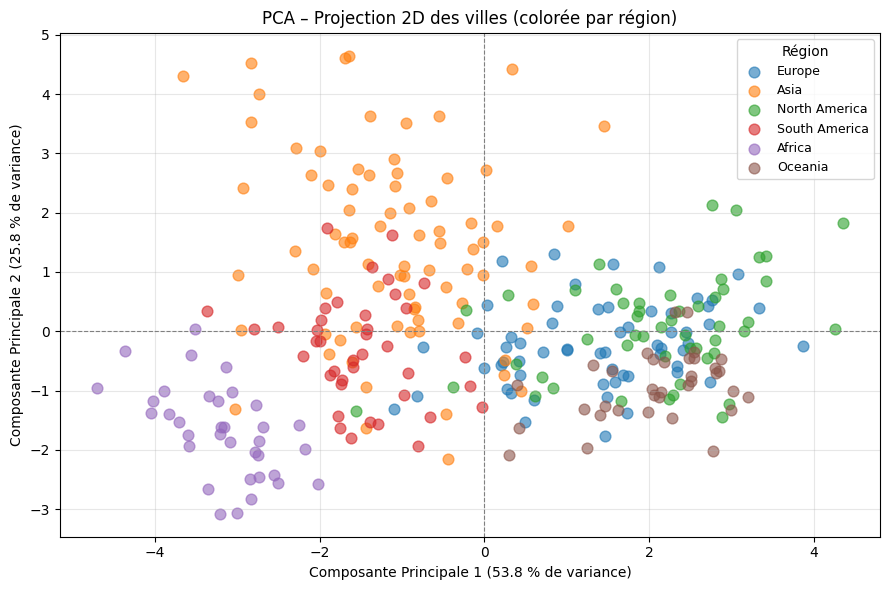

In [27]:
# Récupération des régions
regions = df["country"]

# Variance expliquée
var_pc1 = pca.explained_variance_ratio_[0] * 100
var_pc2 = pca.explained_variance_ratio_[1] * 100

plt.figure(figsize=(9, 6))

for region in regions.unique():
    idx = regions == region
    plt.scatter(
        X_pca[idx, 0],
        X_pca[idx, 1],
        alpha=0.6,
        s=60,
        label=region
    )

plt.xlabel(f"Composante Principale 1 ({var_pc1:.1f} % de variance)")
plt.ylabel(f"Composante Principale 2 ({var_pc2:.1f} % de variance)")
plt.title("PCA – Projection 2D des villes (colorée par région)")

plt.axhline(0, color="grey", linestyle="--", linewidth=0.8)
plt.axvline(0, color="grey", linestyle="--", linewidth=0.8)

plt.legend(title="Région", fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

La projection PCA montre une organisation globale des villes selon deux axes principaux. Le premier axe semble surtout lié aux dimensions économiques et aux infrastructures, avec d’un côté des villes plus développées (principalement en Europe, Amérique du Nord et Océanie) et de l’autre des villes aux niveaux de revenus plus faibles, notamment en Afrique et en Amérique du Sud. Le second axe met davantage en évidence des différences liées à la qualité de vie et à l’environnement.
La coloration par région permet d’observer certaines tendances géographiques, même si les régions ne sont pas parfaitement séparées.

In [41]:
# Création du DataFrame 2D
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])

# Export en CSV
pca_df.to_csv("C:/Users/zara_/tp_final_git/projet_git/outputs/pca_emb_2d.csv", index=False)